# Perceval Quest
#### Author: *Valentin Deumier*

Our goal is to start by creating a 'classical' neural network and train it on the famous MNIST handwritten digits dataset, and then try to upgrade it by using Linear Optical Quantum Computing, in hope to increase the accuracy of the model and lower the duration of the calculations.

### <u>2: A hybrid model</u>

In [184]:
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
from scipy.optimize import minimize
from tqdm import tqdm
import time

from dotenv import load_dotenv
import os
print(np.__version__)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Softmax
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model

import perceval as pcvl
import perceval.providers.scaleway as scw
import perceval.components as comp
from perceval.rendering.circuit import SymbSkin, PhysSkin
from perceval import Circuit
from perceval import catalog
print(pcvl.__version__)

# Parameters
IMG_SIZE = 28
NUM_CLASSES = 10
BATCH_SIZE = 16
EPOCHS = 30

2.0.2
0.12.2


In [185]:
# Scaleway session initialization

load_dotenv()

__SCW_PROJECT_ID = os.getenv("SCW_PROJECT_ID")
__SCW_TOKEN = os.getenv("SCW_SECRET_KEY")

session = scw.Session(
    project_id=__SCW_PROJECT_ID,
    token=__SCW_TOKEN,
    platform="sim:sampling:l4",  # Simulation on Nvidia L4 GPU
    max_idle_duration_s=1200,  # session is automatically revoked after 6 minutes without any new job
    max_duration_s=3600,  # session is automatically revoked after one hour
)

In [186]:
# Data into numpy arrays
def load_data(filename):

    data = pd.read_csv(filename)
    X = np.array(data['image'].str.split(',', expand=True).values)

    # Remove the [ ] from the image data (fastest method I found)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            X[i, j] = X[i, j].replace('[', '').replace(']', '')
    X = X.astype(float)

    y = data['label'].values

    X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)/255.0      # Reshape and normalize
    return X, y

# Get the absolute path to the data folder
script_dir = os.getcwd()
data_dir = os.path.join(script_dir, 'data')

# Load the data
train_file = os.path.join(data_dir, 'train.csv')
X_train, y_train = load_data(train_file)
val_file = os.path.join(data_dir, 'val.csv')
X_val, y_val = load_data(val_file)
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

# Divide the image resolution by 2 using max pooling
X_train = np.array(tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(X_train))/255.0
X_val = np.array(tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(X_val))/255.0

# X_train = np.array(tf.keras.layers.AveragePooling2D(pool_size=(2, 2))(X_train))
# X_val = np.array(tf.keras.layers.AveragePooling2D(pool_size=(2, 2))(X_val))

print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)
EFF_IMG_SIZE = X_train.shape[1]


(6000, 28, 28, 1) (6000,) (600, 28, 28, 1) (600,)
(6000, 14, 14, 1) (6000,) (600, 14, 14, 1) (600,)


The idea here is to encode the image data into quantum data while preserving the 2-dimensional structure of the image. \
\
Like in the CNN model, we want neighbours pixels to remain close to each other in the quantum representation so that we can perform "local" transformation (the equivalent of convoluting the image with a kernel), so the representation has to be continuous along both axis.\
This means that we can't flatten the data, so we can't use basis, angle or amplitude embedding.\
\
An idea could be to encode the image in a matrix representation of a unitary transformation (that could also be parametrized, and have its parameters be optimized).\
\
Being inspired by the solution of Schrodinger's equation for a time-independant Hamiltonian, we are going to represent the image $\mathbf{x}$ as the resulting evolution operator :

$$ U_t(\mathbf{x}) = \exp(-iH_{\mathbf{x}}t) $$

Where $H_{\mathbf{x}}$ is the symetric part of our image matrix (so that $U_t(\mathbf{x})$ is unitary):

$$ H_{\mathbf{x}} = \frac{\mathbf{x} + \mathbf{x}^T}{2} $$

with $t \in \mathbb{R}$ a parameter that we can tweak.

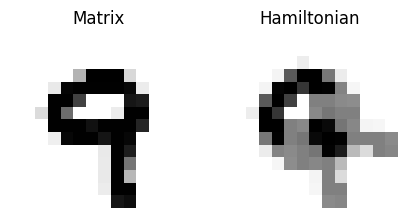

In [187]:
def toHamiltonian(x):
    H = 0.5*(x[:, :, 0] + x[:, :, 0].T)
    return H

def plot_hamiltonian(x):
    L = [x, toHamiltonian(x)]
    labels = ['Matrix', 'Hamiltonian']
    fig, axes = plt.subplots(1, 2, figsize=(5, 5))
    for i in range(2):
        axes[i].imshow(L[i], cmap='gray_r')
        axes[i].set_title(labels[i])
        axes[i].axis('off')
    plt.show()

# Plot the first image and its Hamiltonian
plot_hamiltonian(X_train[1])

This exemple shows that almost half of the information contained in the input image is lost during the encoding process, as we only keep its symetrical part.

Another way of constructing a unitary matrix is by using the *unitary dilation theorem*:

Let $A \in \mathcal{M}_n(\mathbb{C})$ such that its spectral norm verifies $||A|| \le 1$, then

$$ U_A = \begin{bmatrix} A & \sqrt{\mathbb{I} - A A^\dagger} \\ \sqrt{\mathbb{I} - A^\dagger A} & -A^\dagger \end{bmatrix} $$

is a $2n \times 2n$ unitary matrix. 

Therefore, if we normalize our input image, we can implement it as a 2n modes circuit. Since the whole image information is embedded in the upper half of $U_A$, we will consider a 2n modes circuit but we will effectively only work with the first n modes.

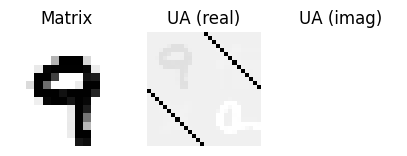

In [188]:
def U(x: np.ndarray, t: float) -> np.ndarray:
    """Compute the unitary operator associated with the Hamiltonian x and time t"""
    H = toHamiltonian(x)
    return linalg.expm(-1j*H*t)

def UA(x: np.ndarray) -> np.ndarray:
    """Compute the unitary operator using unitary dilation"""
    x = x[:, :, 0]
    x = x / (3 * np.linalg.norm(x, ord=2))        # The 3 factor is to ensure that this computation pass the numpy is_unitary test
    identity = np.eye(EFF_IMG_SIZE)
    B = np.block([
        [x, linalg.sqrtm(identity - x @ x.T)],
        [linalg.sqrtm(identity - x.T @ x), -x.T]
    ])
    return B

def plot_UA(x):
    L = [x, np.real(UA(x)), np.imag(UA(x))]
    labels = ['Matrix', 'UA (real)', 'UA (imag)']
    fig, axes = plt.subplots(1, 3, figsize=(5, 5))
    for i in range(3):
        axes[i].imshow(L[i], cmap='gray_r')
        axes[i].set_title(labels[i])
        axes[i].axis('off')
    plt.show()

plot_UA(X_train[1])

# Verify that UA(X_train) is unitary
# for i in range(len(X_val)):
#     unitary_check = np.allclose(UA(X_val[i]).conj().T @ UA(X_val[i]), np.eye(2*EFF_IMG_SIZE))
#     if not unitary_check:
#         print(f"Is UA(X_val[{i}]) unitary?", unitary_check)

# print(np.max(UA(X_train[59]).conj().T @ UA(X_train[59]) - np.eye(2*EFF_IMG_SIZE)))

To reproduce the local effect of the convolution, the next layer will be constituted of a brickwork layout of 2 modes circuits that are acting on modes close to each other.\
\
The operator associated with this layer will be denoted $V(\mathbf{\omega})$, with $\mathbf{\omega}$ being the array of parameters of the 2 modes circuits.\
\
In some papers, we can read that this can be done with SU(N) gates. This is a more optimized approach that could be interesting to try in future upgrades, mainly, we have explicit formulas for the gradient of SU(N) gates that could improve the training time.

In [189]:
def brickwork(
    omega: np.ndarray,
    num_modes: int,
) -> Circuit:
    """
    Create a brickwork circuit with generic 2 modes circuits.
    Args:   
        omega         : generic 2 modes circuits parameters (shape: [EFF_IMG_SIZE - 1, 4])
        num_modes : Width of circuit
    Returns:
        Circuit
    """
    circ = Circuit(num_modes)
    even_modes = np.arange(0, num_modes - 1, 2)
    odd_modes = np.arange(1, num_modes - 1, 2)

    for k in even_modes:
        params = omega[int(k)]
        circ.add(int(k), catalog["generic 2 mode circuit"].build_circuit(theta=params[0], phi_tl=params[1], phi_bl=params[2], phi_tr=params[3]))
    for j in odd_modes:
        params = omega[int(j)]
        circ.add(int(j), catalog["generic 2 mode circuit"].build_circuit(theta=params[0], phi_tl=params[1], phi_bl=params[2], phi_tr=params[3]))

    return circ

def brickwork_BS(
    omega: np.ndarray,
    num_modes: int,
) -> Circuit:
    """
    Create a brickwork circuit with beam splitters.
    Args:   
        omega         : BS parameters (len = num_modes - 1)
        num_modes : Width of circuit
    Returns:
        Circuit
    """
    circ = Circuit(num_modes)
    even_modes = np.arange(0, num_modes - 1, 2)
    odd_modes = np.arange(1, num_modes - 1, 2)

    for k in even_modes:
        circ.add(int(k), comp.BS(omega[int(k)]))
    for j in odd_modes:
        circ.add(int(j), comp.BS(omega[int(j)]))
   
    return circ

In [190]:
if EFF_IMG_SIZE % 2 == 0:       # Number of photons
    N = EFF_IMG_SIZE//2      
else:
    N = EFF_IMG_SIZE//2 + 1

m = EFF_IMG_SIZE * 2      # Number of modes   
L = 3       # Number of layers

# Input state with N photons and m modes
input_state = pcvl.BasicState([1, 0]*N + [0]*(m-2*N))
print("Input state:", input_state)

# Random parameters for the circuit initialization
omega_params = np.random.uniform(0, 2*np.pi, (L, (EFF_IMG_SIZE-1), 4))
BS_params = np.random.uniform(0, 2*np.pi, EFF_IMG_SIZE-1)

print("Total number of parameters:", omega_params.size + BS_params.size)

Input state: |1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0>
Total number of parameters: 169


The code will follow the following scheme:

- Use the fonction **create_circuit(x, params)** that create the circuit with L layers $U_A(\mathbf{x}) V(\mathbf{\omega})$ associated to the image $\mathbf{x}$.

- Construct an output of the circuit that can be used in an optimisation algorithm. Here, I had two ideas:
    * Use the average number of photons in each mode in order to compute a softmax probability for each category, and then optimize the circuit using a cross-entropy loss function and standard gradient descent techniques.
    * Use the average number of photons in each mode in order to compute a single value between 0 and 9 (for example, the spatial weighted average over the modes), and here I again had two ideas:
        - Use a genetic algorithm approach
        - Use a regression method to which thresholds are applied in order to categorize.
I have decided to go with the last option.

- Convert the output into a predicted label (not an integer) by computing a weighted average of the spatial distribution

- Compute the MSE loss

- Do a minimization step using derivatives-free algorithms.

Once the minimization of the loss is done, the thresholds will be optimized on the training set in order to yield the highest accuracy

For the circuit construction, I have realised that the unitary matrix tends to shift photons from one half of the circuit to the other.

Therefore, I have adapted the position of the optical components accordingly.

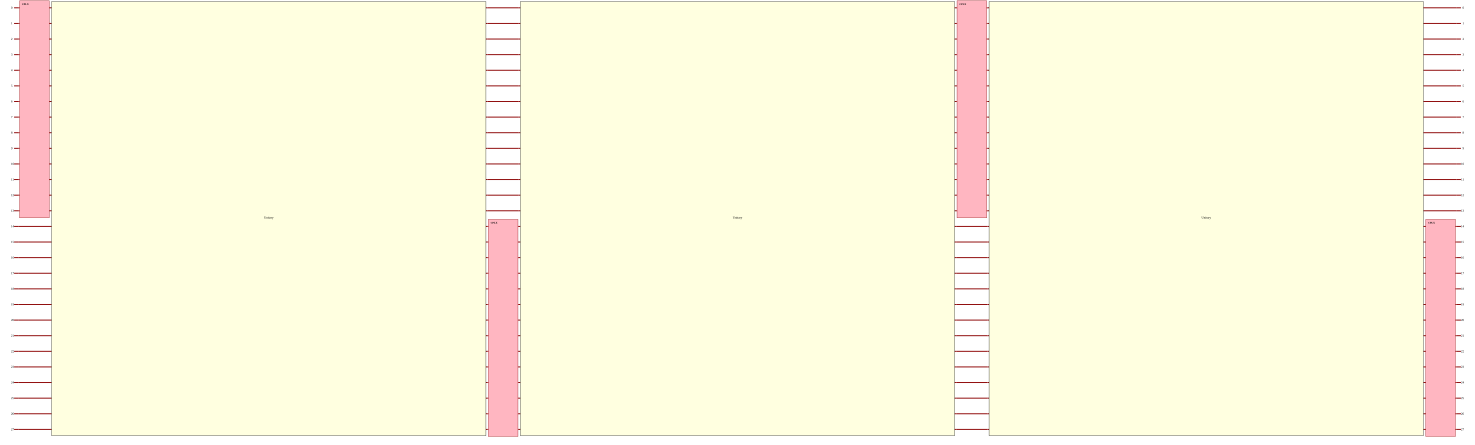

In [191]:
def create_circuit(x, BS_params, omega_params):
    c = Circuit(m)
    c.add(0, brickwork_BS(BS_params, EFF_IMG_SIZE))
    for i in range(L):
        i_odd = 1 - i%2 
        c.add(0, comp.Unitary(U=pcvl.Matrix(UA(x))))
        c.add(i_odd*EFF_IMG_SIZE, brickwork(omega_params[i], EFF_IMG_SIZE))
    return c

c = create_circuit(X_train[1], BS_params, omega_params)
pcvl.pdisplay(c, render_size=0.25)

For an implementation on a real QPU, we will consider a sample of the circuit output distribution, and the mean circuit output value will be used as the model output before it is converted to a predicted label.

When L is even, almost all photons end up in the top modes, and when L is odd, almost all photons end up in the bottom modes.

In [192]:
N_SAMPLES = 5000

L_odd = L%2
ps_condition = "["
for i in range(EFF_IMG_SIZE):
    ps_condition += f"{i + L_odd*EFF_IMG_SIZE},"
ps_condition = ps_condition[:-1] + f"] == {N}"
print(ps_condition)
ps = pcvl.utils.postselect.PostSelect(ps_condition)

def sample_prob(x, BS_params, omega_params, processor):
    processor.set_circuit(create_circuit(x, BS_params, omega_params))
    processor.with_input(input_state)
    processor.set_postselection(ps)
    sampler = pcvl.algorithm.Sampler(processor, max_shots_per_call=N_SAMPLES)
    sample_count = sampler.sample_count(N_SAMPLES)
    return sample_count

def mean_output(x, BS_params, omega_params, processor):
    prob_dist = sample_prob(x, BS_params, omega_params, processor)
    mean_output = np.zeros(EFF_IMG_SIZE)
    for output, count in prob_dist['results'].items():
        for i in range(EFF_IMG_SIZE):
            mean_output[i] += output[i + (L%2)*EFF_IMG_SIZE]*count
    return mean_output/N_SAMPLES

# def test_mean_output(x, BS_params, omega_params):

#     processor = pcvl.components.processor.Processor("CliffordClifford2017")
#     processor.set_circuit(create_circuit(x, BS_params, omega_params))
#     processor.with_input(input_state)
#     processor.set_postselection(ps)

#     m_o_list = []
#     label_list = []
#     for n_s in range(1, 20000, 100):
#         prob_dist = pcvl.algorithm.Sampler(processor, max_shots_per_call=n_s).sample_count(n_s)
#         mean_output = np.zeros(EFF_IMG_SIZE)
#         for output, count in prob_dist['results'].items():
#             for i in range(EFF_IMG_SIZE):
#                 mean_output[i] += output[i]*count
#         mean_output = mean_output/n_s
#         label = np.clip(np.sqrt(np.abs(np.average(range(EFF_IMG_SIZE), weights=mean_output) - 6.5))*9 - 1, 0, 10)
#         m_o_list.append(mean_output)
#         label_list.append(label)

#     plt.plot(np.arange(1, 20000, 100), label_list, 'x')
#     plt.title("Label prediction vs number of samples")
#     plt.xlabel("Number of samples")
#     plt.ylabel("Label")
#     plt.savefig("label_vs_samples.png")
#     plt.show()

# test_mean_output(X_train[1], BS_params, omega_params)

[14,15,16,17,18,19,20,21,22,23,24,25,26,27] == 7


To convert the output state of the circuit into a predicted label, my intuition is to think of the output state as a spatial distribution of guesses:
* The more there are photons close to the top mode, the more the predicted label is close to 0
* The more there are photons close to the bottom mode, the more the predicted label is close to 9

I have decided to take the exponential of this spatial distribution, so that the output is less biased towards middle values like 4 or 5. \
In the label_distribution.py file, it is shown that the *output_to_float_label_flat* function leads to a less biased label distribution.

In [193]:
# Convert from the repartition of photon in the mean output to a label
def output_to_int_label(output):
    return int(np.round(np.average(range(EFF_IMG_SIZE), weights=np.exp(output) - np.ones(EFF_IMG_SIZE))*9/(EFF_IMG_SIZE - 1)))       # Scale the output to the range [0, 9]

def output_to_float_label(output):
    return np.average(range(EFF_IMG_SIZE), weights=np.exp(output) - np.ones(EFF_IMG_SIZE))*9/(EFF_IMG_SIZE - 1)

def output_to_float_label_flat(output):
    return np.clip(np.sqrt(np.abs(np.average(range(EFF_IMG_SIZE), weights=output) - 6.5))*9 - 1, 0, 10)

This turned out to not be a great idea as the central limit theorem forces the model to output values sampled from a gaussian distribution, whether or not a transformation to strech it is applied. It is therefore hard for the model to output values that are outside of this gaussian distribution.\
\
The idea to remedy this problem is to have a classical NN layer at the end of the optical system, that takes the mean spatial distribution as input, and outputs a label.

In [202]:
def classical_layer(input_size, hidden_units, num_classes):
    model = Sequential([
        Dense(hidden_units, input_dim=input_size, activation='relu'),
        Dense(num_classes),
        Softmax()
    ])
    return model

In [195]:
def MSE_loss(y_true, y_pred):
    """ Compute the MSE loss of a batch of predictions 
    Args:
        y_true : Array of true labels
        y_pred : Array of predicted labels
    """
    return np.mean((y_true - y_pred)**2)

def minibatch_loss(X, y, BS_params, omega_params, processor):
    """ Compute the loss of a minibatch of data 
    Args:
        X : Array of images
        y : Array of labels
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
    """
    y_pred = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        mean_output_i = mean_output(X[i], BS_params, omega_params, processor)
        label_i = output_to_float_label_flat(mean_output_i)
        y_pred[i] = label_i
    return MSE_loss(y, y_pred)

def image_loss(X, y, BS_params, omega_params, processor):
    """ Compute the loss of a single image 
    Args:
        X : Image
        y : Label
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
    """
    mean_output_i = mean_output(X, BS_params, omega_params, processor)
    label_i = output_to_float_label_flat(mean_output_i)
    return MSE_loss(y, label_i)

In [196]:
def optimize_thresholds(y_true, y_pred, num_classes=10, max_steps=100):
    """ Optimize the thresholds to maximize accuracy on training data
    Args:
        y_true : Array of true labels (int)
        y_pred : Array of predicted labels (float)
        num_classes : Number of classes
    Returns:
        thresholds : Array of optimized thresholds
    """
    def loss(thresholds):
        thresholds = np.sort(thresholds)
        thresholds = np.concatenate(([0], thresholds, [10]))
        y_pred_int = np.digitize(y_pred, thresholds) - 1
        return -accuracy_score(y_true, y_pred_int)

    initial_thresholds = np.linspace(0, 10, num_classes + 1)[1:-1]  # Exclude the first and last thresholds
    bounds = [(0, 10) for _ in range(len(initial_thresholds))]
    result = minimize(loss, initial_thresholds, method='Nelder-Mead', bounds=bounds, options={'maxiter': max_steps})
    optimized_thresholds = np.concatenate(([0], np.sort(result.x), [10]))  # Add back the first and last thresholds

    return optimized_thresholds, -result.fun

In [197]:
def model_accuracy(y_pred, y_true, thresholds):
    """ Compute the accuracy of the model on a dataset 
    Args:
        y_pred : Array of predicted labels (float)
        y_true : Array of true labels (int)
        thresholds : Array of thresholds
    """
    y_pred_int = np.digitize(y_pred, thresholds) - 1
    return accuracy_score(y_true, y_pred_int)

In [198]:
def minimize_step_batch(batch_X, batch_Y, BS_params, omega_params, processor, learning_rate=0.04):
    """ Perform a single step of the minimization algorithm 
    Args:
        batch_X : Array of images
        batch_Y : Array of labels
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
        learning_rate : Learning rate of the algorithm
    """
    epsilon = 0.1
    grad_BS_params = np.zeros_like(BS_params)
    grad_omega_params = np.zeros_like(omega_params)
    loss = minibatch_loss(batch_X, batch_Y, BS_params, omega_params, processor)

    # Compute the gradient with respect to BS_params
    for i in range(len(BS_params)):
        BS_params[i] += epsilon
        loss_plus = minibatch_loss(batch_X, batch_Y, BS_params, omega_params, processor)
        BS_params[i] -= epsilon
        grad_BS_params[i] = (loss_plus - loss) / epsilon

    # Compute the gradient with respect to omega_params
    for i in range(len(omega_params)):
        for j in range(omega_params.shape[1]):
            omega_params[i, j] += epsilon
            loss_plus = minibatch_loss(batch_X, batch_Y, BS_params, omega_params, processor)
            omega_params[i, j] -= epsilon
            grad_omega_params[i, j] = (loss_plus - loss) / epsilon

    # Update the parameters
    grad_params = np.concatenate((grad_BS_params, grad_omega_params.flatten()))
    print("Max gradient value :", np.max(np.abs(grad_params)))
    print("Avg gradient value :", np.mean(np.abs(grad_params)))
    BS_params -= learning_rate * grad_BS_params
    omega_params -= learning_rate * grad_omega_params

    # Compute the loss after the update
    loss = minibatch_loss(batch_X, batch_Y, BS_params, omega_params, processor)

    return BS_params, omega_params, loss


def minimize_step_image(X, Y, BS_params, omega_params, processor, learning_rate=5*10e-3):
    """ Perform a single step of the minimization algorithm 
    Args:
        X : Image
        Y : Label
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
        learning_rate : Learning rate of the algorithm
    """
    epsilon = 0.1
    grad_BS_params = np.zeros_like(BS_params)
    grad_omega_params = np.zeros_like(omega_params)

    # Compute the gradient with respect to BS_params
    for i in range(len(BS_params)):
        BS_params[i] += epsilon
        loss_plus = image_loss(X, Y, BS_params, omega_params, processor)
        BS_params[i] -= 2 * epsilon
        loss_minus = image_loss(X, Y, BS_params, omega_params, processor)
        BS_params[i] += epsilon
        grad_BS_params[i] = (loss_plus - loss_minus) / (2 * epsilon)

    # Compute the gradient with respect to omega_params
    for i in range(len(omega_params)):
        for j in range(omega_params.shape[1]):
            omega_params[i, j] += epsilon
            loss_plus = image_loss(X, Y, BS_params, omega_params, processor)
            omega_params[i, j] -= 2 * epsilon
            loss_minus = image_loss(X, Y, BS_params, omega_params, processor)
            omega_params[i, j] += epsilon
            grad_omega_params[i, j] = (loss_plus - loss_minus) / (2 * epsilon)

    # Update the parameters
    grad_params = np.concatenate((grad_BS_params, grad_omega_params.flatten()))
    print("Max gradient value :", np.max(np.abs(grad_params)))
    print("Avg gradient value :", np.mean(np.abs(grad_params)))
    BS_params -= learning_rate * grad_BS_params
    omega_params -= learning_rate * grad_omega_params

    # Compute the loss after the update
    loss = image_loss(X, Y, BS_params, omega_params, processor)

    return BS_params, omega_params, loss


In [199]:
def nelder_mead(f, x_start,
                step=0.1, no_improve_thr=10e-6,
                no_improv_break=5, max_iter=0,
                alpha=1., gamma=2., rho=-0.5, sigma=0.5):
    """
    Nelder-Mead algorithm.
    Args:
        f (function): The objective function to be minimized.
        x_start (numpy array): Initial guess.
        step (float): Look-around radius in initial step.
        no_improve_thr (float): Break after no_improv_break iterations with no improvement.
        no_improv_break (int): Number of iterations with no improvement to break after.
        max_iter (int): Maximum number of iterations.
        alpha (float): Reflection coefficient.
        gamma (float): Expansion coefficient.
        rho (float): Contraction coefficient.
        sigma (float): Shrink coefficient.
    Returns:
        Best parameter array.
    """
    # Initial simplex
    dim = len(x_start)
    prev_best = f(x_start)
    no_improv = 0
    res = [[x_start, prev_best]]
    
    for i in range(dim):
        x = x_start.copy()
        x[i] = x[i] + step
        score = f(x)
        res.append([x, score])
    
    iters = 0
    while True:
        # Order
        res.sort(key=lambda x: x[1])
        best = res[0][1]
        
        # Break after max_iter
        if max_iter and iters >= max_iter:
            return res[0]
        
        iters += 1
        
        # Break after no_improv_break iterations with no improvement
        if best < prev_best - no_improve_thr:
            no_improv = 0
            prev_best = best
        else:
            no_improv += 1
        
        if no_improv >= no_improv_break:
            return res[0]
        
        print(f"Current best: {best}        Current iteration: {iters}")
        
        # Centroid
        x0 = [0.] * dim
        for tup in res[:-1]:
            for i in range(dim):
                x0[i] += tup[0][i] / (len(res) - 1)
        
        # Reflection
        xr = x0 + alpha * (x0 - res[-1][0])
        rscore = f(xr)
        if res[0][1] <= rscore < res[-2][1]:
            del res[-1]
            res.append([xr, rscore])
            continue
        
        # Expansion
        if rscore < res[0][1]:
            xe = x0 + gamma * (xr - x0)
            escore = f(xe)
            if escore < rscore:
                del res[-1]
                res.append([xe, escore])
                continue
            else:
                del res[-1]
                res.append([xr, rscore])
                continue
        
        # Contraction
        xc = x0 + rho * (res[-1][0] - x0)
        cscore = f(xc)
        if cscore < res[-1][1]:
            del res[-1]
            res.append([xc, cscore])
            continue
        
        # Shrink
        x1 = res[0][0]
        nres = []
        for tup in res:
            redx = x1 + sigma * (tup[0] - x1)
            score = f(redx)
            nres.append([redx, score])
        res = nres


def minimize_step_image_df(X, Y, BS_params, omega_params, processor, max_steps=10):
    """ Perform a single step of the minimization algorithm using a derivative-free optimization method
    Args:
        X : Image
        Y : Label
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
        learning_rate : Learning rate of the algorithm
        max_steps : Maximum number of steps for the minimization algorithm
    """
    omega_shape = omega_params.shape
    BS_len = len(BS_params)

    def loss_function(params):
        BS_params_f, omega_params_f = np.split(params, [len(BS_params)])
        omega_params_f = omega_params_f.reshape(omega_shape)
        return image_loss(X, Y, BS_params_f, omega_params_f, processor)
    
    initial_params = np.concatenate([BS_params, omega_params.flatten()])
    result = nelder_mead(loss_function, initial_params, max_iter=max_steps)
    
    optimized_params = result[0]
    BS_params, omega_params = np.split(optimized_params, [BS_len])
    omega_params = omega_params.reshape(omega_shape)
    
    loss = image_loss(X, Y, BS_params, omega_params, processor)
    
    return BS_params, omega_params, loss

def minimize_step_batch_df(batch_X, batch_Y, BS_params, omega_params, processor, max_steps=100):
    """ Perform a single step of the minimization algorithm using a derivative-free optimization method"
    Args:
        batch_X : Array of images
        batch_Y : Array of labels
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
        max_steps : Maximum number of steps for the minimization algorithm
    """
    omega_shape = omega_params.shape
    BS_len = len(BS_params)

    def loss_function(params):
        BS_params_f, omega_params_f = np.split(params, [len(BS_params)])
        omega_params_f = omega_params_f.reshape(omega_shape)
        return minibatch_loss(batch_X, batch_Y, BS_params_f, omega_params_f, processor)
    
    initial_params = np.concatenate([BS_params, omega_params.flatten()])
    result = nelder_mead(loss_function, initial_params, max_iter=max_steps)
    
    optimized_params = result[0]
    BS_params, omega_params = np.split(optimized_params, [BS_len])
    omega_params = omega_params.reshape(omega_shape)
    
    loss = minibatch_loss(batch_X, batch_Y, BS_params, omega_params, processor)
    
    return BS_params, omega_params, loss

# Test

# processor = pcvl.components.processor.Processor("CliffordClifford2017")

# BS_old = BS_params.copy()
# omega_old = omega_params.copy()
# ind = 1000
# X_batch = X_train[ind:ind+BATCH_SIZE]
# y_batch = y_train[ind:ind+BATCH_SIZE]
# print("Initial loss:", minibatch_loss(X_batch, y_batch, BS_params, omega_params, processor))
# BS_params, omega_params, loss = minimize_step_batch(X_batch, y_batch, BS_params, omega_params, processor)
# print("Final loss:", loss)

# print("Number of updated parameters:", np.sum(np.abs(BS_params - BS_old) > 1e-4) + np.sum(np.abs(omega_params - omega_old) > 1e-4))
# print("Index of updated parameters:", np.where(np.abs(BS_params - BS_old) > 1e-4), np.where(np.abs(omega_params - omega_old) > 1e-4))
# print("Max parameter difference (BS, omega) :", np.max(np.abs(BS_params - BS_old)), np.max(np.abs(omega_params - omega_old)))
# print("Avg parameter difference (BS, omega) :", np.mean(np.abs(BS_params - BS_old)), np.mean(np.abs(omega_params - omega_old)))

In [ ]:
processor = pcvl.components.processor.Processor("CliffordClifford2017")

def train_SPSA(BS_params, omega_params, processor, a=0.01, c=0.01, hidden_units=16, epochs=10):
    """ Train the model using the SPSA algorithm
    Args:
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
        processor : Quantum processor
        learning_rate : Learning rate of the algorithm
        a : SPSA parameter
        c : SPSA parameter
        max_iter : Maximum number of iterations for the SPSA algorithm
    """
    omega_shape = omega_params.shape
    BS_len = len(BS_params)
    params = np.concatenate([BS_params, omega_params.flatten()])
    classifier = classical_layer(EFF_IMG_SIZE, hidden_units, NUM_CLASSES)

    loss_history = []
    val_acc_history = []

    for epoch in range(epochs):
        print("Epoch :", epoch)
        shuffled_indices = np.random.permutation(len(X_train))

        for k in tqdm(range(int(X_train.shape[0]/BATCH_SIZE)), desc="Training with SPSA"):

            batch_indices = shuffled_indices[k*BATCH_SIZE:min((k+1)*BATCH_SIZE, len(X_train))]
            batch_X = X_train[batch_indices]
            batch_Y = y_train[batch_indices]

            ak = a / (k + 1)**0.602
            ck = c / (k + 1)**0.101
            delta = 2 * np.random.randint(2, size=params.shape) - 1

            params_plus = params + ck * delta
            params_minus = params - ck * delta

            BS_params_plus, omega_params_plus = np.split(params_plus, [BS_len])
            omega_params_plus = omega_params_plus.reshape(omega_shape)
            loss_plus = minibatch_loss(batch_X, batch_Y, BS_params_plus, omega_params_plus, processor)

            BS_params_minus, omega_params_minus = np.split(params_minus, [BS_len])
            omega_params_minus = omega_params_minus.reshape(omega_shape)
            loss_minus = minibatch_loss(batch_X, batch_Y, BS_params_minus, omega_params_minus, processor)

            gk = (loss_plus - loss_minus) / (2 * ck * delta)
            params = params - ak * gk

        BS_params, omega_params = np.split(params, [BS_len])
        omega_params = omega_params.reshape(omega_shape)

        # Compute the thresholds
        y_pred = np.zeros(len(X_train))
        for i in range(len(X_train)):
            mean_output_i = mean_output(X_train[i], BS_params, omega_params, processor)
            label_i = output_to_float_label_flat(mean_output_i)
            y_pred[i] = label_i
        thresholds, _ = optimize_thresholds(y_train, y_pred)

        # Compute the total loss
        loss = MSE_loss(y_train, y_pred)
        loss_history.append(loss)
        print("Total loss:", loss)

        # Compute the validation accuracy
        y_val_pred = np.zeros(len(X_val))
        for i in range(len(X_val)):
            mean_output_i = mean_output(X_val[i], BS_params, omega_params, processor)
            label_i = output_to_float_label_flat(mean_output_i)
            y_val_pred[i] = label_i
            
        val_acc = model_accuracy(y_val_pred, y_val, thresholds)
        val_acc_history.append(val_acc)
        print("Validation accuracy:", val_acc)

    return BS_params, omega_params, loss_history, val_acc_history

BS_params, omega_params, loss_history, val_acc_history = train_SPSA(BS_params, omega_params, processor, a=0.01, c=0.01, epochs=10)

# Save the parameters

# Ensure the directory exists
modelparams_dir = os.path.join(script_dir, 'modelparams')
os.makedirs(modelparams_dir, exist_ok=True)

# Save the parameters
np.save(os.path.join(modelparams_dir, 'BS_params_params.npy'), BS_params)
np.save(os.path.join(modelparams_dir, 'omega_params.npy'), omega_params)
np.save(os.path.join(modelparams_dir, 'loss_history.npy'), loss_history)
np.save(os.path.join(modelparams_dir, 'val_acc_history.npy'), val_acc_history)

# Plot the loss history
plt.plot(loss_history)
plt.xlabel("Number of batches")
plt.ylabel("Loss")
plt.title("Loss history")
plt.grid()

plt.savefig(os.path.join(modelparams_dir, "loss_history.png"))
plt.show()


Epoch : 0


Training with SPSA:   0%|          | 1/375 [00:08<52:17,  8.39s/it]


KeyboardInterrupt: 

Epoch : 0


Training with CMA-ES:   0%|          | 0/375 [00:00<?, ?it/s]

(9_w,18)-aCMA-ES (mu_w=5.4,w_1=30%) in dimension 117 (seed=653840, Thu Mar 20 23:08:36 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     18 7.232577686126399e+00 1.0e+00 2.89e-01  3e-01  3e-01 0:53.9
    2     36 7.214878591166482e+00 1.0e+00 2.81e-01  3e-01  3e-01 1:46.7


Training with CMA-ES:   0%|          | 1/375 [01:46<11:05:01, 106.69s/it]

Loss : 7.214878591166482
(9_w,18)-aCMA-ES (mu_w=5.4,w_1=30%) in dimension 117 (seed=622811, Thu Mar 20 23:10:23 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     18 7.943126176818874e+00 1.0e+00 2.89e-01  3e-01  3e-01 0:50.7
    2     36 7.843089013924275e+00 1.0e+00 2.80e-01  3e-01  3e-01 1:43.8


...

Training with CMA-ES: 100%|█████████▉| 374/375 [11:07:04<01:44, 104.64s/it]

Loss : 9.146461941855716
(9_w,18)-aCMA-ES (mu_w=5.4,w_1=30%) in dimension 117 (seed=659713, Fri Mar 21 10:15:40 2025)
Iterat #Fevals   function value  axis ratio  sigma  min&max std  t[m:s]
    1     18 1.033713554082679e+01 1.0e+00 2.90e-01  3e-01  3e-01 0:51.5
    2     36 1.019053929918099e+01 1.0e+00 2.82e-01  3e-01  3e-01 1:42.6


Training with CMA-ES: 100%|██████████| 375/375 [11:08:46<00:00, 107.00s/it]

Loss : 10.190539299180994


Validation accuracy: 0.10833333333333334


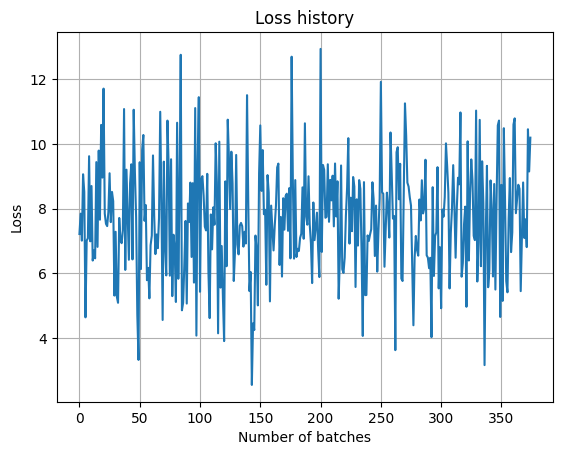

In [ ]:
import cma

processor = pcvl.components.processor.Processor("CliffordClifford2017")

def train_batch_CMAES(BS_params, omega_params, processor, epochs=10, sigma=0.3):
    """ Train the model using the CMA-ES algorithm
    Args:
        BS_params : Array of BS parameters
        omega_params : Array of omega parameters
        processor : Quantum processor
        epochs : Number of epochs
        sigma : Initial standard deviation for the CMA-ES algorithm
    """
    omega_shape = omega_params.shape
    BS_len = len(BS_params)
    params = np.concatenate([BS_params, omega_params.flatten()])

    loss_history = []
    val_acc_history = []

    for epoch in range(epochs):
        print("Epoch :", epoch)
        shuffled_indices = np.random.permutation(len(X_train))

        for k in tqdm(range(int(X_train.shape[0] / BATCH_SIZE)), desc="Training with CMA-ES"):
            batch_indices = shuffled_indices[k * BATCH_SIZE: min((k + 1) * BATCH_SIZE, len(X_train))]
            batch_X = X_train[batch_indices]
            batch_Y = y_train[batch_indices]

            def loss_function(params):
                BS_params_f, omega_params_f = np.split(params, [BS_len])
                omega_params_f = omega_params_f.reshape(omega_shape)
                return minibatch_loss(batch_X, batch_Y, BS_params_f, omega_params_f, processor)

            es = cma.CMAEvolutionStrategy(params, sigma)
            es.optimize(loss_function, iterations=2)
            params = es.result.xbest
            loss = es.result.fbest
            loss_history.append(loss)
            print("Loss :", loss)

        BS_params, omega_params = np.split(params, [BS_len])
        omega_params = omega_params.reshape(omega_shape)

        # Compute the thresholds
        y_pred = np.zeros(len(X_train))
        for i in range(len(X_train)):
            mean_output_i = mean_output(X_train[i], BS_params, omega_params, processor)
            label_i = output_to_float_label_flat(mean_output_i)
            y_pred[i] = label_i
        thresholds, _ = optimize_thresholds(y_train, y_pred)

        # Compute the total loss
        # loss = MSE_loss(y_train, y_pred)
        # loss_history.append(loss)
        # print("Total loss:", loss)

        # Compute the validation accuracy
        y_val_pred = np.zeros(len(X_val))
        for i in range(len(X_val)):
            mean_output_i = mean_output(X_val[i], BS_params, omega_params, processor)
            label_i = output_to_float_label_flat(mean_output_i)
            y_val_pred[i] = label_i

        val_acc = model_accuracy(y_val_pred, y_val, thresholds)
        val_acc_history.append(val_acc)
        print("Validation accuracy:", val_acc)

    return BS_params, omega_params, loss_history, val_acc_history

# Example usage
BS_params, omega_params, loss_history, val_acc_history = train_batch_CMAES(BS_params, omega_params, processor, epochs=1, sigma=0.3)

# Save the parameters

# Ensure the directory exists
modelparams_dir = os.path.join(script_dir, 'modelparams')
os.makedirs(modelparams_dir, exist_ok=True)

# Save the parameters
np.save(os.path.join(modelparams_dir, 'BS_params_params.npy'), BS_params)
np.save(os.path.join(modelparams_dir, 'omega_params.npy'), omega_params)
np.save(os.path.join(modelparams_dir, 'loss_history.npy'), loss_history)
np.save(os.path.join(modelparams_dir, 'val_acc_history.npy'), val_acc_history)

# Plot the loss history
plt.plot(loss_history)
plt.xlabel("Number of batches")
plt.ylabel("Loss")
plt.title("Loss history")
plt.grid()

plt.savefig(os.path.join(modelparams_dir, "loss_history.png"))
plt.show()

In [ ]:
# Training loop (batch)

processor = pcvl.components.processor.Processor("CliffordClifford2017")
debug = True

def train(X_train, y_train, X_val, y_val, BS_params, omega_params, learning_rate=0.04, epochs=1):
    loss_history = []
    val_acc_history = []

    for epoch in range(epochs):
        print("Epoch", epoch)
        shuffled_indices = np.random.permutation(len(X_train))

        for batch in tqdm(range(0, len(X_train), BATCH_SIZE), desc="Training"):
            batch_indices = shuffled_indices[batch: min(batch + BATCH_SIZE, len(X_train))]
            x = X_train[batch_indices]
            y_true = y_train[batch_indices]
            BS_params, omega_params, loss = minimize_step_batch(x, y_true, BS_params, omega_params, processor, learning_rate=learning_rate)
            print("Loss:", loss)
            if debug:
                print("BS_params:", BS_params)
                print("omega_params[0:3]:", omega_params[0:3])
            loss_history.append(loss)

        # Compute the thresholds
        y_pred = np.zeros(len(X_train))
        for i in range(len(X_train)):
            mean_output_i = mean_output(X_train[i], BS_params, omega_params, processor)
            label_i = output_to_float_label_flat(mean_output_i)
            y_pred[i] = label_i
        thresholds, _ = optimize_thresholds(y_train, y_pred)

        # Compute the validation accuracy
        y_val_pred = np.zeros(len(X_val))
        for i in range(len(X_val)):
            mean_output_i = mean_output(X_val[i], BS_params, omega_params, processor)
            label_i = output_to_float_label_flat(mean_output_i)
            y_val_pred[i] = label_i
            
        val_acc = model_accuracy(y_val_pred, y_val, thresholds)
        val_acc_history.append(val_acc)
        print("Validation accuracy:", val_acc)

    return BS_params, omega_params, loss_history, val_acc_history

BS_params, omega_params, loss_history, val_acc_history = train(X_train, y_train, X_val, y_val, BS_params, omega_params, epochs=1)

# Save the parameters

# Ensure the directory exists
modelparams_dir = os.path.join(script_dir, 'modelparams')
os.makedirs(modelparams_dir, exist_ok=True)

# Save the parameters
np.save(os.path.join(modelparams_dir, 'BS_params_params.npy'), BS_params)
np.save(os.path.join(modelparams_dir, 'omega_params.npy'), omega_params)
np.save(os.path.join(modelparams_dir, 'loss_history.npy'), loss_history)
np.save(os.path.join(modelparams_dir, 'val_acc_history.npy'), val_acc_history)

# Plot the loss history
plt.plot(loss_history)
plt.xlabel("Number of batches")
plt.ylabel("Loss")
plt.title("Loss history")
plt.grid()

plt.savefig(os.path.join(modelparams_dir, "loss_history.png"))
plt.show()

In [ ]:
# Training loop (Image)

processor = pcvl.components.processor.Processor("CliffordClifford2017")
debug = True

def train(X_train, y_train, X_val, y_val, BS_params, omega_params, learning_rate=10e-6, epochs=1):
    loss_history = []
    val_acc_history = []

    for epoch in range(epochs):
        print("Epoch", epoch)
        shuffled_indices = np.random.permutation(len(X_train))

        for i in tqdm(shuffled_indices, desc="Training"):
            if debug:
                BS_params_old = BS_params.copy()
                omega_params_old = omega_params.copy()
            x = X_train[i]
            y_true = y_train[i]
            BS_params, omega_params, loss = minimize_step_image_df(x, y_true, BS_params, omega_params, processor, max_steps=100)
            if debug:
                print("Number of modified parameters: ", np.sum(np.abs(BS_params - BS_params_old) > 0.01) + np.sum(np.abs(omega_params - omega_params_old) > 0.01))
                print("Index of modified parameters (BS, omega): ", np.where(np.abs(BS_params - BS_params_old) > 0.01), np.where(np.abs(omega_params - omega_params_old) > 0.01))
            print("Loss:", loss)
            loss_history.append(loss)

        thresholds = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

        y_val_pred = np.zeros(len(X_val))
        for i in range(len(X_val)):
            mean_output_i = mean_output(X_val[i], BS_params, omega_params, processor)
            label_i = output_to_float_label_flat(mean_output_i)
            y_val_pred[i] = label_i

        val_acc = model_accuracy(y_val_pred, y_val, thresholds)
        val_acc_history.append(val_acc)
        print("Validation accuracy:", val_acc)
    return BS_params, omega_params, loss_history, val_acc_history

BS_params, omega_params, loss_history, val_acc_history = train(X_train, y_train, X_val, y_val, BS_params, omega_params, epochs=1)

# Save the parameters

# Ensure the directory exists
modelparams_dir = os.path.join(script_dir, 'modelparams')
os.makedirs(modelparams_dir, exist_ok=True)

# Save the parameters
np.save(os.path.join(modelparams_dir, 'BS_params_params.npy'), BS_params)
np.save(os.path.join(modelparams_dir, 'omega_params.npy'), omega_params)
np.save(os.path.join(modelparams_dir, 'loss_history.npy'), loss_history)
np.save(os.path.join(modelparams_dir, 'val_acc_history.npy'), val_acc_history)

# Plot the loss history
plt.plot(loss_history)
plt.xlabel("Number of images")
plt.ylabel("Loss")
plt.title("Loss history")
plt.grid()

plt.savefig(os.path.join(modelparams_dir, "loss_history.png"))
plt.show()

In [ ]:
# Plot confusion matrix

# TODO

In [ ]:
# Test de optimize thresholds

# th = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
# y_pred = np.clip(y_train + np.random.normal(0, 0.1, len(y_train)), 0, 10)
# thresholds, accuracy = optimize_thresholds(y_train, y_pred)

# print("Naive thresholds:", th, "Naive accuracy:", accuracy_score(y_train, np.digitize(y_pred, th) - 1))
# print("Optimized thresholds:", thresholds, "Optimized accuracy:", accuracy)

Naive thresholds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] Naive accuracy: 0.5426666666666666
Optimized thresholds: [ 0.          0.7829421   1.74882464  3.5444178   3.61934041  4.6479077
  5.34544068  6.60604944  7.63092396  8.35892677 10.        ] Optimized accuracy: 0.8935


In [ ]:
modelparams_dir = os.path.join(script_dir, 'modelparams')
os.makedirs(modelparams_dir, exist_ok=True)

In [ ]:
# Load the parameters

BS_params = np.load(os.path.join(modelparams_dir, 'BS_params_params.npy'))
omega_params = np.load(os.path.join(modelparams_dir, 'omega_params.npy'))
loss_history = np.load(os.path.join(modelparams_dir, 'loss_history.npy'))
val_acc_history = np.load(os.path.join(modelparams_dir, 'val_acc_history.npy'))

print("Validarion accuracy:", val_acc_history[-1])

# Evaluate the model

# print("Training accuracy:", model_accuracy(X_train, y_train, t_params, omega_params))
# print("Validation accuracy:", model_accuracy(X_val, y_val, t_params, omega_params))

Validarion accuracy: 0.10833333333333334
